# Migas-1.5 Counterfactual Scenario Simulation

What happens to a forecast when the news changes? Most time-series models can't answer that question — they only see numbers. Migas-1.5 fuses **text and time series**, so you can literally rewrite the narrative and watch the forecast respond.

This notebook walks you through **counterfactual scenario analysis**: we take a real forecast window, swap the predictive-signals text for a synthetic bullish or bearish scenario, re-run the forecast, and measure how much the prediction shifted. This is a direct way to probe the model's sensitivity to textual inputs and to understand the value of multimodal fusion.

**What you will learn:**
- How Migas-1.5 summaries are structured (factual vs. predictive sections)
- How hand-written counterfactual narratives can steer a forecast
- How to re-forecast with modified text and compare against the original
- How to quantify the trend impact using directional metrics
- How Best-of-N selection works when an LLM server is available

**Requirements:** Install the package from the repo root (`uv sync`). The main bullish/bearish walkthrough below uses hand-written scenario text, so it runs **without** vLLM. A vLLM server is only required for the **Best-of-N candidate generation** section later in the notebook (`VLLM_BASE_URL` / `VLLM_MODEL`, default: `http://localhost:8004/v1`, model: `openai/gpt-oss-120b`). This notebook uses a committed crude-oil sample under `data/oil_scenario_sim.json`.

**See also:** [Inference Quick Start](migas-1.5-inference-quickstart.ipynb) · [Backtest and Metrics](migas-1.5-backtest-and-metrics.ipynb)

In [15]:
import warnings
warnings.filterwarnings("ignore", message="IProgress not found")

import json, sys
from textwrap import dedent
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import HTML, display
from IPython import get_ipython

ipython = get_ipython()
if ipython is not None:
    ipython.run_line_magic("matplotlib", "inline")

from migaseval import MigasPipeline

sys.path.insert(0, "..")
from scripts.plotting_utils import COLORS, apply_migas_style
from scripts.counterfactual_utils import (
    splice_summary,
    extract_factual,
    extract_predictive,
    generate_scenario_texts,
    plot_scenario_comparison,
    display_text_comparison,
    composite_trend_score,
    linear_slope,
)

apply_migas_style()

pipeline = MigasPipeline.from_pretrained("Synthefy/migas-1.5", device="cuda")
print("Pipeline loaded.")

Initialized univariate models: chronos, timesfm (prophet on-demand)
Pipeline loaded.


## Load a sample window

Every summary has two parts:

- **FACTUAL SUMMARY** — describes what already happened (price movements, supply data, geopolitical events).
- **PREDICTIVE SIGNALS** — the model's forward-looking interpretation of the text.

The counterfactual experiment targets the predictive section: we keep the facts, but rewrite the outlook.

In [16]:
sample_path = "../data/oil_scenario_sim.json"
pred_len = 16

with open(sample_path, "r") as f:
    sample = json.load(f)

seq_len = len(sample["history_scaled"])
context = np.array(sample["history_scaled"], dtype=np.float32)
ground_truth = np.array(sample["ground_truth_unscaled"], dtype=np.float32)
original_summary = sample["summary"]
h_mean, h_std = sample["history_mean"], sample["history_std"]

context_unscaled = context * h_std + h_mean

print(f"Context length: {seq_len}")
print(f"Pred length:    {pred_len}")
print(f"Price range:    ${context_unscaled.min():.2f} – ${context_unscaled.max():.2f}")
print(f"Summary length: {len(original_summary)} chars")

Context length: 128
Pred length:    16
Price range:    $58.50 – $75.89
Summary length: 1777 chars


In [17]:
print("=" * 70)
print(extract_factual(original_summary))
print()
print("=" * 70)
print(extract_predictive(original_summary))

FACTUAL SUMMARY:**  
Across the 64 timesteps the market narrative has been dominated by alternating spikes in oil prices driven by geopolitical shocks (Ukraine‑Russia tensions, U.S.‑China and U.S.‑India tariff threats, and occasional OPEC⁺ output hikes) and sharp pull‑backs whenever inventory builds, sanctions, or aggressive OPEC⁺ supply expansions were announced.  Equity markets have repeatedly rallied on expectations of Federal Reserve rate cuts—most often priced for an October‑December easing cycle—while tech‑heavy indices have shown volatility around AI earnings and tariff‑related risk‑off moves.  Energy‑sector fundamentals have been strained by low U.S. rig counts, persistent oversupply, and a wave of workforce reductions at majors, yet occasional price spikes (e.g., when Brent breached $70 / bbl) have kept oil‑linked stocks intermittently buoyant.

**

PREDICTIVE SIGNALS:**  
Analysts expect the near‑term oil price trajectory to hinge on three catalysts: (1) the outcome of the Au

## Baseline forecast

First, run Migas-1.5 with the **original, unmodified summary**. This is the baseline we will compare counterfactual scenarios against.

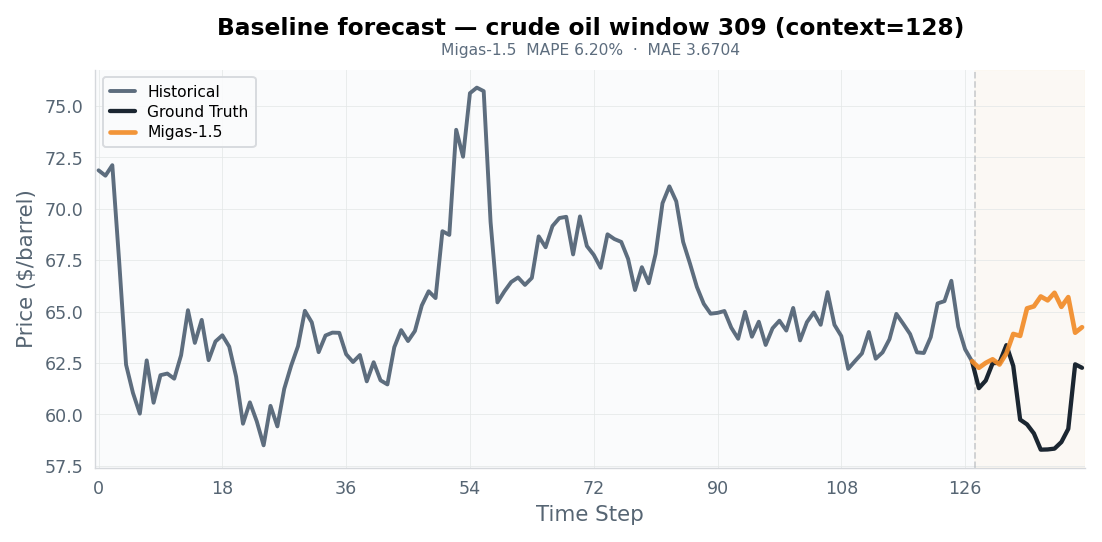

Forecast slope:       +0.20853
Forecast trend score: +0.134


In [18]:
original_forecast = pipeline.predict(
    context=context_unscaled[np.newaxis],
    summaries=[original_summary],
    pred_len=pred_len,
).squeeze().cpu().numpy()

from scripts.plotting_utils import plot_forecast_single

fig, ax = plot_forecast_single(
    context_unscaled, ground_truth,
    {"Migas-1.5": original_forecast},
    seq_len, pred_len,
    title=f"Baseline forecast — crude oil window {sample['index']} (context={seq_len})",
)
ax.set_ylabel("Price ($/barrel)")
plt.show()

print(f"Forecast slope:       {linear_slope(original_forecast):+.5f}")
print(f"Forecast trend score: {composite_trend_score(original_forecast, 'up', context_unscaled):+.3f}")

## The core idea: rewrite the narrative, shift the forecast

Here is the key insight behind counterfactual scenario analysis:

1. **Keep the facts** — the factual summary stays the same (what already happened doesn't change).
2. **Rewrite the outlook** — we replace only the predictive-signals paragraph with a bullish (or bearish) scenario.
3. **Re-forecast** — feed the spliced summary back to Migas-1.5 and observe how the prediction changes.

If the model truly integrates text with time series, the forecast should shift in the direction of the new narrative. This is not a trivial result: the model's numerical backbone (Chronos) sees the exact same numbers — only the text embedding changes.

For the first bullish/bearish walkthrough we use hand-written predictive signals so this notebook works without a local LLM server. The **Best-of-N** section later uses a local vLLM server to generate multiple candidate narratives and automatically pick the strongest one.

## Hand-written bullish counterfactual

To keep the main walkthrough lightweight, we manually provide a bullish `PREDICTIVE SIGNALS` block and splice it onto the original factual summary.

In [19]:

bullish_predictive = dedent(
    """
    PREDICTIVE SIGNALS: Crude oil has broken out of the recent consolidation and is now climbing in a sustained upward leg, with fresh highs repeatedly overtaking prior peaks as market liquidity tightens. At the same time, inventory draws across key storage hubs are accelerating, reinforcing the view that a durable supply deficit is forming and pushing market participants to add aggressively to long positions.
    """
).strip()

bullish_summary = splice_summary(original_summary, bullish_predictive)

display(HTML(display_text_comparison(original_summary, bullish_summary)))

## Re-forecast with the bullish scenario

Now we run the same context window through Migas-1.5, but with the counterfactual summary. The numerical input is identical — only the text embedding changes.

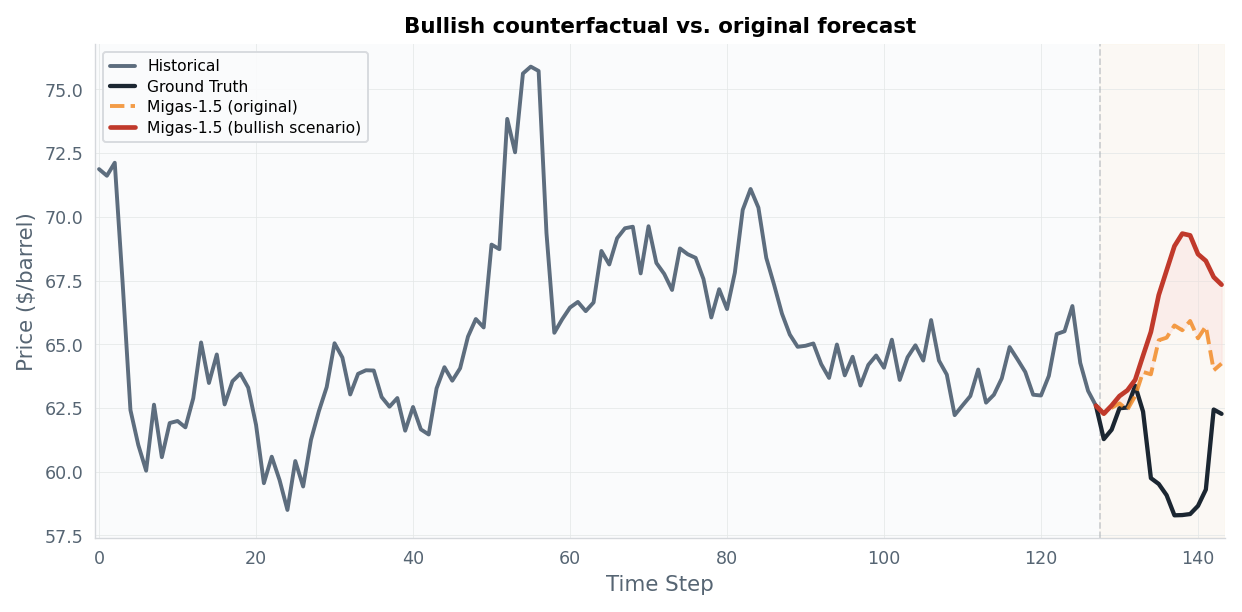

Original slope:       +0.20853
Bullish slope:        +0.47423
Slope shift:          +0.26570
Trend score (orig):   +0.134
Trend score (bull):   +0.181


In [20]:
bullish_forecast = pipeline.predict(
    context=context_unscaled[np.newaxis],
    summaries=[bullish_summary],
    pred_len=pred_len,
).squeeze().cpu().numpy()

fig, ax = plot_scenario_comparison(
    context_unscaled,
    original_forecast,
    bullish_forecast,
    ground_truth=ground_truth,
    direction="up",
    title="Bullish counterfactual vs. original forecast",
)
ax.set_ylabel("Price ($/barrel)")
plt.show()

orig_slope = linear_slope(original_forecast)
bull_slope = linear_slope(bullish_forecast)
print(f"Original slope:       {orig_slope:+.5f}")
print(f"Bullish slope:        {bull_slope:+.5f}")
print(f"Slope shift:          {bull_slope - orig_slope:+.5f}")
print(f"Trend score (orig):   {composite_trend_score(original_forecast, 'up', context_unscaled):+.3f}")
print(f"Trend score (bull):   {composite_trend_score(bullish_forecast, 'up', context_unscaled):+.3f}")

## Hand-written bearish counterfactual

The same experiment works in reverse. Here we manually provide a bearish `PREDICTIVE SIGNALS` block and see whether the forecast bends downward.

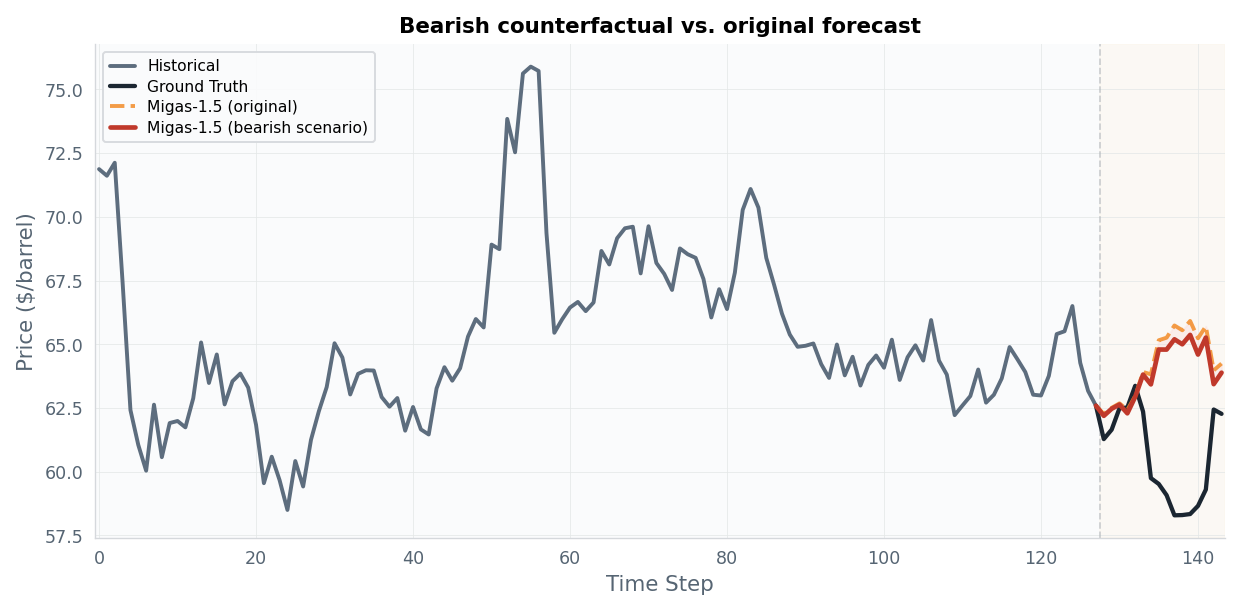

Original slope:       +0.20853
Bearish slope:        +0.17037
Slope shift:          -0.03816


In [21]:
bearish_predictive = dedent(
    """
    PREDICTIVE SIGNALS: Crude oil has entered a sustained downturn, slipping out of its recent range as downside momentum builds and each rebound stalls more quickly than the last. Demand concerns are intensifying alongside visible inventory builds and softer global growth expectations, leading traders to lean harder into short positioning and reinforcing the market's negative tone.
    """
).strip()

bearish_summary = splice_summary(original_summary, bearish_predictive)

display(HTML(display_text_comparison(original_summary, bearish_summary)))

bearish_forecast = pipeline.predict(
    context=context_unscaled[np.newaxis],
    summaries=[bearish_summary],
    pred_len=pred_len,
).squeeze().cpu().numpy()

fig, ax = plot_scenario_comparison(
    context_unscaled,
    original_forecast,
    bearish_forecast,
    ground_truth=ground_truth,
    direction="down",
    title="Bearish counterfactual vs. original forecast",
)
ax.set_ylabel("Price ($/barrel)")
plt.show()

bear_slope = linear_slope(bearish_forecast)
print(f"Original slope:       {orig_slope:+.5f}")
print(f"Bearish slope:        {bear_slope:+.5f}")
print(f"Slope shift:          {bear_slope - orig_slope:+.5f}")

## All three together

Let's overlay the original, bullish, and bearish forecasts on a single plot to visualize the full range of text-driven scenario steering.

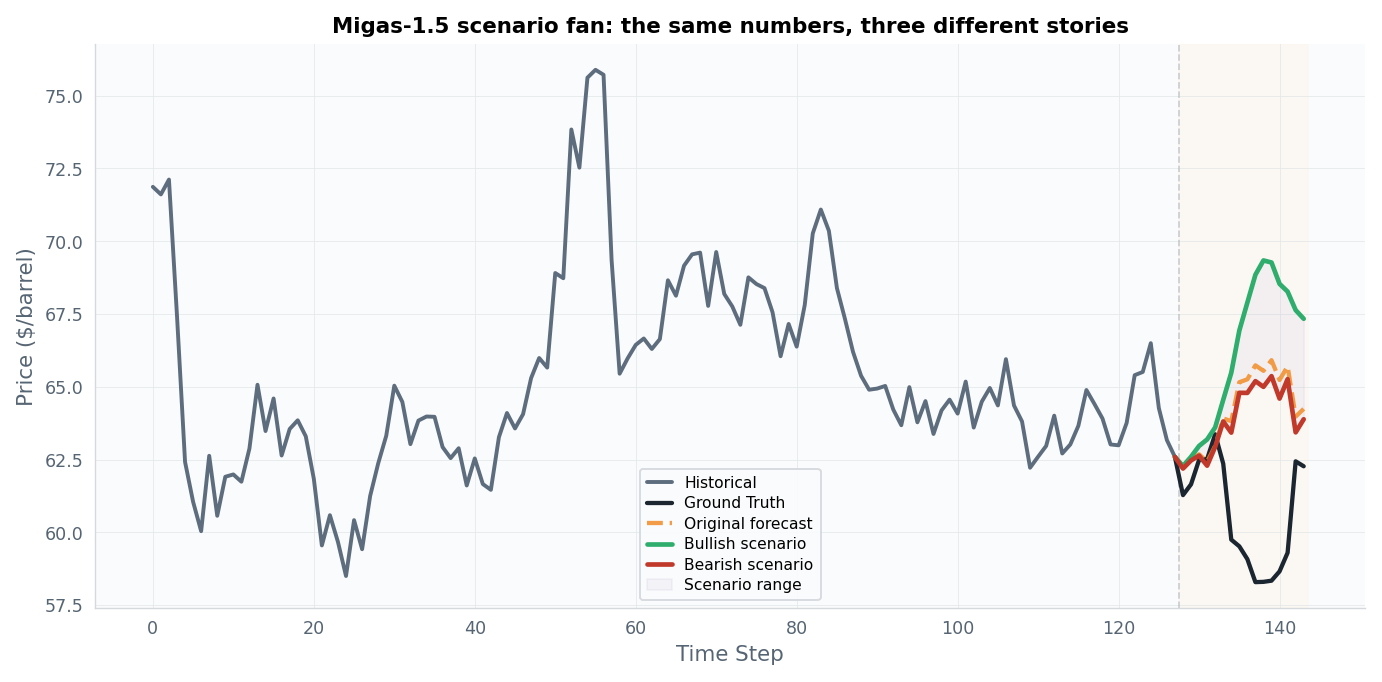

In [22]:
from scripts.plotting_utils import _draw_forecast_region, COLORS

BULLISH_COLOR = "#2EAD6D"
BEARISH_COLOR = "#C0392B"

fig, ax = plt.subplots(figsize=(10, 5))
_draw_forecast_region(ax, seq_len, pred_len)

t_ctx = np.arange(seq_len)
t_pred = np.arange(seq_len - 1, seq_len + pred_len)
last_val = float(context_unscaled[-1])

ax.plot(t_ctx, context_unscaled, color=COLORS["historical"], lw=2.0,
        label="Historical", solid_capstyle="round")
ax.plot(t_pred, np.concatenate([[last_val], ground_truth]),
        color=COLORS["ground_truth"], lw=2.2, label="Ground Truth", solid_capstyle="round")
ax.plot(t_pred, np.concatenate([[last_val], original_forecast]),
        color=COLORS["Migas-1.5"], lw=2.2, ls="--", label="Original forecast",
        alpha=0.85, solid_capstyle="round")
ax.plot(t_pred, np.concatenate([[last_val], bullish_forecast]),
        color=BULLISH_COLOR, lw=2.4, label="Bullish scenario", solid_capstyle="round")
ax.plot(t_pred, np.concatenate([[last_val], bearish_forecast]),
        color=BEARISH_COLOR, lw=2.4, label="Bearish scenario", solid_capstyle="round")

ax.fill_between(
    t_pred,
    np.concatenate([[last_val], bearish_forecast]),
    np.concatenate([[last_val], bullish_forecast]),
    alpha=0.08, color="#9B8EC4", label="Scenario range",
)

ax.set_xlabel("Time Step", color="#566573")
ax.set_ylabel("Price ($/barrel)", color="#566573")
ax.set_title("Migas-1.5 scenario fan: the same numbers, three different stories",
             fontsize=11, fontweight=600)
ax.legend(fontsize=8, handlelength=1.6, labelspacing=0.35, borderpad=0.45)
fig.tight_layout(pad=1.2)
plt.show()

## Understanding the trend metrics

To quantify how much a counterfactual scenario steers the forecast, we use a suite of directional metrics:

| Metric | What it measures |
|--------|------------------|
| **Linear slope** | Slope of a least-squares fit through the forecast. Positive = upward. |
| **Endpoint change** | Relative change from first to last predicted value. |
| **Monotonicity** | Fraction of consecutive steps moving in the desired direction (0–1). |
| **Breakout ratio** | How far the forecast extends beyond the historical range. |
| **Composite trend score** | Weighted combination of all the above (positive = aligned with direction). |
| **Slope shift** | Difference in slope between counterfactual and original forecast. |

Let's compare our three forecasts:

In [23]:
from scripts.counterfactual_utils import endpoint_change, monotonicity, breakout_ratio

rows = []
for label, fc, direction in [
    ("Original",  original_forecast, "up"),
    ("Bullish",   bullish_forecast,  "up"),
    ("Bearish",   bearish_forecast,  "down"),
]:
    rows.append({
        "Scenario": label,
        "Slope": f"{linear_slope(fc):+.5f}",
        "Endpoint Δ": f"{endpoint_change(fc):+.3f}",
        "Monotonicity": f"{monotonicity(fc, direction):.2f}",
        "Breakout": f"{breakout_ratio(fc, context_unscaled, direction):.4f}",
        "Trend Score": f"{composite_trend_score(fc, direction, context_unscaled):+.3f}",
    })

metrics_df = pd.DataFrame(rows)
display(metrics_df.style.set_caption("Trend metrics across scenarios"))

,Scenario,Slope,Endpoint Δ,Monotonicity,Breakout,Trend Score
0,Original,+0.20853,+0.032,0.67,0.0000,+0.134
1,Bullish,+0.47423,+0.081,0.67,0.0000,+0.181
2,Bearish,+0.17037,+0.027,0.40,0.0000,-0.399


## Best-of-N scenario selection

A single LLM generation might not produce the most impactful scenario text. **Best-of-N selection** generates multiple candidate narratives, runs each through Migas-1.5, and keeps the one that produces the strongest trend shift.

This section **does require a local vLLM server** because the candidate narratives are generated on the fly. It is a model-in-the-loop approach: we don't just pick text that *sounds* bullish — we pick text that actually *steers the forecast*. The selection criterion is the composite trend score.

In [24]:
n_candidates = 5

print(f"Generating {n_candidates} candidate texts and scoring each through Migas-1.5...")

candidates = generate_scenario_texts(
    [context_unscaled],
    direction="up",
    asset_name="crude oil",
    n_candidates=n_candidates,
    temperature=0.7,
)

candidate_scores = []
candidate_forecasts = []
for i, text in enumerate(candidates[0]):
    cf_summary = splice_summary(original_summary, text)
    fc = pipeline.predict(
        context=context_unscaled[np.newaxis],
        summaries=[cf_summary],
        pred_len=pred_len,
    ).squeeze().cpu().numpy()
    score = composite_trend_score(fc, "up", context_unscaled)
    candidate_scores.append(score)
    candidate_forecasts.append(fc)
    print(f"  Candidate {i+1}: trend score = {score:+.3f}  |  slope = {linear_slope(fc):+.5f}")

best_idx = int(np.argmax(candidate_scores))
print(f"\nWinner: candidate {best_idx + 1} (score {candidate_scores[best_idx]:+.3f})")

Generating 5 candidate texts and scoring each through Migas-1.5...
  Candidate 1: trend score = +0.185  |  slope = +0.35891
  Candidate 2: trend score = +0.179  |  slope = +0.26711
  Candidate 3: trend score = +0.225  |  slope = +0.30778
  Candidate 4: trend score = +0.175  |  slope = +0.25710
  Candidate 5: trend score = +0.181  |  slope = +0.28479

Winner: candidate 3 (score +0.225)


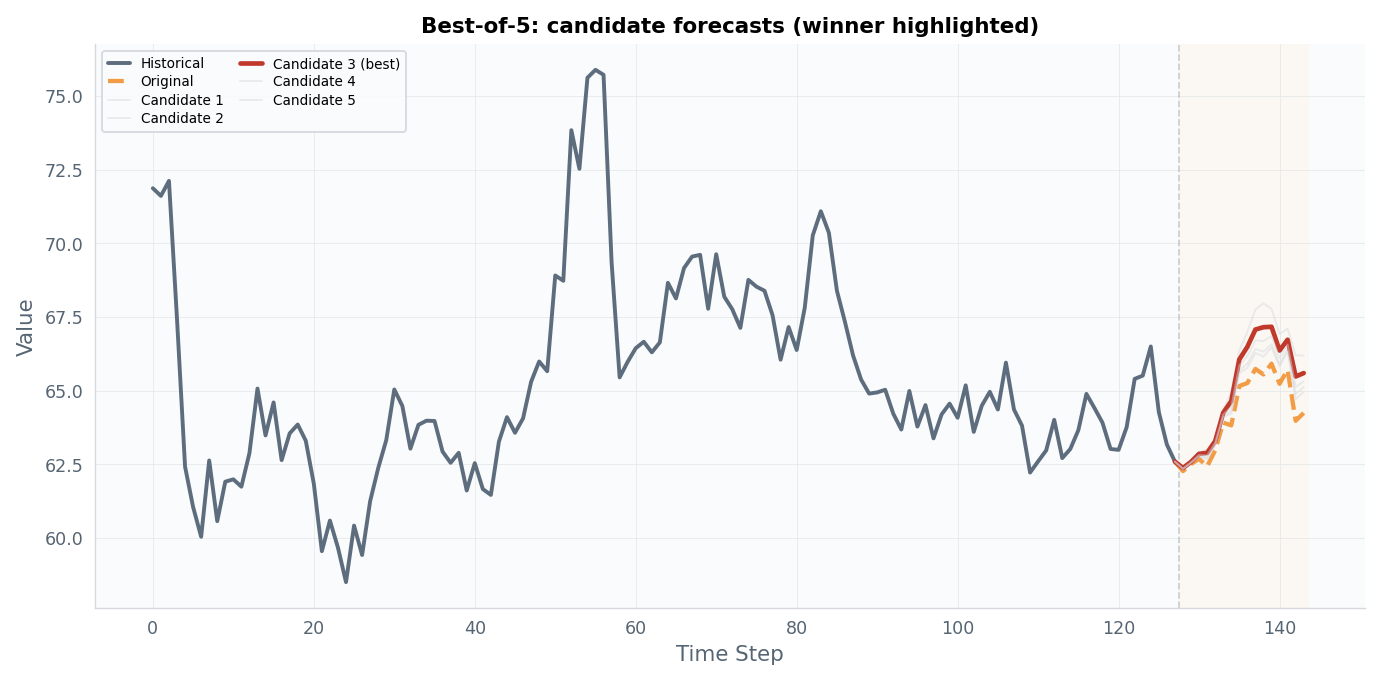

In [25]:
BEST_COLOR = "#C0392B"
REST_COLOR = "#D5D8DC"

fig, ax = plt.subplots(figsize=(10, 5))
_draw_forecast_region(ax, seq_len, pred_len)

ax.plot(t_ctx, context_unscaled, color=COLORS["historical"], lw=2.0,
        label="Historical", solid_capstyle="round")
ax.plot(t_pred, np.concatenate([[last_val], original_forecast]),
        color=COLORS["Migas-1.5"], lw=2.2, ls="--", label="Original",
        alpha=0.85, solid_capstyle="round")

for i, fc in enumerate(candidate_forecasts):
    is_best = (i == best_idx)
    ax.plot(
        t_pred, np.concatenate([[last_val], fc]),
        color=BEST_COLOR if is_best else REST_COLOR,
        lw=2.4 if is_best else 1.0,
        alpha=1.0 if is_best else 0.45,
        label=f"Candidate {i+1}{' (best)' if is_best else ''}",
        solid_capstyle="round",
    )

ax.set_xlabel("Time Step", color="#566573")
ax.set_ylabel("Value", color="#566573")
ax.set_title(f"Best-of-{n_candidates}: candidate forecasts (winner highlighted)",
             fontsize=11, fontweight=600)
ax.legend(fontsize=7, ncol=2, handlelength=1.6, labelspacing=0.3, borderpad=0.45)
fig.tight_layout(pad=1.2)
plt.show()

## What's next

You've seen how Migas-1.5 responds to counterfactual text scenarios — the forecast genuinely shifts when the narrative changes, while the numerical input stays the same. Here are some directions to explore:

- **Try your own data** — see [Bring Your Own Data](migas-1.5-bring-your-own-data.ipynb) to run counterfactual scenarios on any time series with text.
- **Batch evaluation** — see [Backtest and Metrics](migas-1.5-backtest-and-metrics.ipynb) for running full rolling-window evaluations with ground truth.

The counterfactual utilities used in this notebook live in `scripts/counterfactual_utils/` — feel free to use them in your own experiments.